# Tuần 03 — Thực hành kNN: 4 bài

Demo `01_Demo-kNN.ipynb` dừng ở việc **vote nhãn cho một mẫu test**.

Notebook này có **4 bài**. Mỗi bài là một bộ dữ liệu trên Kaggle. Cả 4 bài đều làm.

Viết hàm kNN một lần ở phần chung (NumPy, không dùng `KNeighborsClassifier`), rồi áp vào từng bài. Điền các ô có `???`. Giữ `np.random.seed(3000)`.

Tải đủ 4 file, đặt vào thư mục `data/`:

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Iris Species | https://www.kaggle.com/datasets/uciml/iris | `data/Iris.csv` |
| 2 | Palmer Penguins | https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data | `data/penguins_size.csv` |
| 3 | Heart Failure Prediction | https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction | `data/heart.csv` |
| 4 | Mushroom Classification | https://www.kaggle.com/datasets/uciml/mushroom-classification | `data/mushrooms.csv` |


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)

c:\ProgramData\miniforge3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 3.60k/3.60k [00:00<00:00, 864kB/s]

Extracting files...
Path to dataset files: C:\Users\MR BAO\.cache\kagglehub\datasets\uciml\iris\versions\2


In [2]:
import os
import pandas as pd

# Xem danh sách các file trong thư mục đã tải
print(os.listdir(path)) 
# Thường file sẽ có tên là 'Iris.csv' hoặc 'iris.csv'

# Đọc file CSV thành DataFrame
csv_path = os.path.join(path, "Iris.csv")
df = pd.read_csv(csv_path)

['database.sqlite', 'Iris.csv']


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("parulpandey/palmer-archipelago-antarctica-penguin-data")

print("Path to dataset files:", path)

100%|██████████| 11.3k/11.3k [00:00<00:00, 1.02MB/s]

Extracting files...
Path to dataset files: C:\Users\MR BAO\.cache\kagglehub\datasets\parulpandey\palmer-archipelago-antarctica-penguin-data\versions\1


In [5]:
import os
import pandas as pd

# Xem danh sách các file trong thư mục đã tải
print(os.listdir(path)) 

# Đọc file CSV thành DataFrame
csv_path = os.path.join(path, "penguins_size.csv")
df = pd.read_csv(csv_path)

['penguins_lter.csv', 'penguins_size.csv']


In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path)

100%|██████████| 8.56k/8.56k [00:00<?, ?B/s]

Extracting files...
Path to dataset files: C:\Users\MR BAO\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1


In [7]:
import os
import pandas as pd

# Xem danh sách các file trong thư mục đã tải
print(os.listdir(path)) 

csv_path = os.path.join(path, "heart.csv")
df = pd.read_csv(csv_path)

['heart.csv']


In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/mushroom-classification")

print("Path to dataset files:", path)

100%|██████████| 34.2k/34.2k [00:00<00:00, 682kB/s]

Extracting files...
Path to dataset files: C:\Users\MR BAO\.cache\kagglehub\datasets\uciml\mushroom-classification\versions\1


In [9]:
import os
import pandas as pd

# Xem danh sách các file trong thư mục đã tải
print(os.listdir(path)) 

csv_path = os.path.join(path, "mushrooms.csv")
df = pd.read_csv(csv_path)

['mushrooms.csv']


In [3]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder

np.set_printoptions(precision=3, suppress=True)


## Phần chung — hàm kNN

Các bài bên dưới gọi lại 4 hàm này.

**Chuẩn hóa min–max**, min/max tính trên từng cột của `x_train`, rồi áp cùng hai mốc đó cho `x_test`. Cột nào `max == min` thì giữ nguyên.

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

**Khoảng cách Euclid** từ một mẫu test tới mọi dòng train:

$$
d_i = \sqrt{\sum_j (test_j - train_{i,j})^2}
$$

**Một mẫu:** lấy `K` chỉ số gần nhất (`np.argsort`), vote nhãn xuất hiện nhiều nhất. Hòa thì `np.argmax` trên `counts` chọn nhãn có mã nhỏ hơn.

**Cả tập test:** gọi dự đoán từng mẫu, trả về mảng nhãn cùng độ dài `x_test`.


In [10]:
def chuan_hoa_minmax(x_train, x_test):
    x_train = np.array(x_train, dtype=float)
    x_test = np.array(x_test, dtype=float)
    
    min_val = np.min(x_train, axis=0)
    max_val = np.max(x_train, axis=0)
    
    diff = max_val - min_val
    diff[diff == 0] = 1.0 
    
    x_train_scaled = (x_train - min_val) / diff
    x_test_scaled = (x_test - min_val) / diff
    return x_train_scaled, x_test_scaled


def tinh_khoang_cach(test_s, x_train):
    """test_s shape (n_feature,), x_train shape (n_train, n_feature).
    Trả về khoảng cách shape (n_train,).
    """
    diff = x_train - test_s
    dist = np.sqrt(np.sum(diff**2, axis=1))    
    return dist


def du_doan_1_mau(test_s, x_train, y_train, K):
    dist = tinh_khoang_cach(test_s, x_train)    
    k_indices = np.argsort(dist)[:K]    
    k_labels = np.array(y_train)[k_indices]    
    classes, counts = np.unique(k_labels, return_counts=True)    
    best_idx = np.argmax(counts)    
    return classes[best_idx]


def du_doan_tap(x_test, x_train, y_train, K):
    y_pred = []
    for test_s in x_test:
        pred = du_doan_1_mau(test_s, x_train, y_train, K)
        y_pred.append(pred)      
    return np.array(y_pred)


In [12]:
def chia_train_test(X, Y, ty_le=0.8, seed=3000):
    np.random.seed(seed)
    rand_indices = np.arange(len(Y))
    np.random.shuffle(rand_indices)
    n_train = int(ty_le * len(Y))
    train_idx = rand_indices[:n_train]
    test_idx = rand_indices[n_train:]
    return X[train_idx], Y[train_idx], X[test_idx], Y[test_idx]


def accuracy(y_pred, y_test):
    return np.mean(y_pred == y_test)


def ve_accuracy_theo_K(x_train, y_train, x_test, y_test, ds_K=None):
    if ds_K is None:
        ds_K = [1, 3, 5, 7, 9, 11, 13, 15]
    ds_acc = [accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test) for K in ds_K]
    print(list(zip(ds_K, np.round(ds_acc, 3))))
    plt.figure(figsize=(6, 4))
    plt.plot(ds_K, ds_acc, marker='o')
    plt.xlabel('K')
    plt.ylabel('accuracy')
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.show()
    return ds_K, ds_acc


---

# Bài 1 — Iris

Nguồn: https://www.kaggle.com/datasets/uciml/iris

File `data/Iris.csv`. 150 bông, 3 loài.

Cột: `Id`, `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`, `Species`.

- Bỏ cột `Id`. Đó là số thứ tự, không phải số đo của hoa.
- Bốn cột đo là số (cm). Nhãn `Species` là chữ: dùng `LabelEncoder`.
- Chuẩn hóa min–max, rồi so sánh accuracy khi **có** và **không** chuẩn hóa (`K=5`).
- In kiểm tra mẫu test đầu tiên (khoảng cách K láng giềng, nhãn của họ, nhãn đoán, nhãn thật), rồi vẽ accuracy theo K.


In [29]:
import os
import numpy as np
import kagglehub

path = kagglehub.dataset_download("uciml/iris")
print("Đường dẫn thư mục hiện tại:", path)

print("Các file có trong thư mục:", os.listdir(path))

csv_path = os.path.join(path, "Iris.csv")
raw_iris = np.genfromtxt(csv_path, delimiter=',', dtype=str, skip_header=1)
print(raw_iris.shape)
print(raw_iris[0])

# TODO: X_iris float (bỏ Id), Y_iris int
X_iris = raw_iris[:, 1:-1].astype(float)
Y_str = raw_iris[:, -1]

_, Y_iris = np.unique(Y_str, return_inverse=True)

print(X_iris.shape, Y_iris.shape)
print(np.unique(Y_iris, return_counts=True))


Đường dẫn thư mục hiện tại: C:\Users\MR BAO\.cache\kagglehub\datasets\uciml\iris\versions\2
Các file có trong thư mục: ['database.sqlite', 'Iris.csv']
(150, 6)
['1' '5.1' '3.5' '1.4' '0.2' 'Iris-setosa']
(150, 4) (150,)
(array([0, 1, 2]), array([50, 50, 50]))


K=5 khoảng cách nhỏ nhất: [0.114 0.342 0.349 0.364 0.419]
Nhãn của 5 láng giềng  : [2 2 2 2 2]
Nhãn dự đoán           : 2
Nhãn thực tế y_test[0] : 2
----------------------------------------
accuracy K=5, đã chuẩn hóa: 0.9666666666666667
accuracy K=5, chưa chuẩn hóa: 0.9666666666666667
[(1, np.float64(0.967)), (3, np.float64(0.967)), (5, np.float64(0.967)), (7, np.float64(0.967)), (9, np.float64(0.967)), (11, np.float64(0.967)), (13, np.float64(0.967)), (15, np.float64(0.967))]


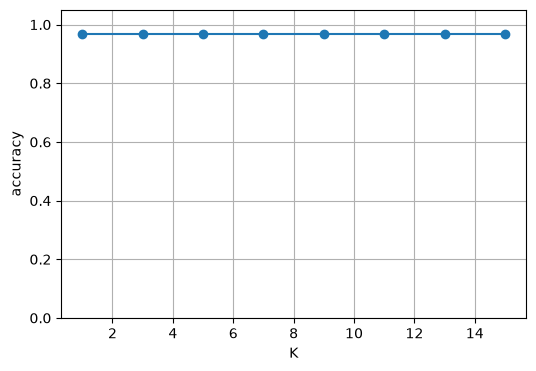

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667)])

In [25]:
x_train, y_train, x_test, y_test = chia_train_test(X_iris, Y_iris)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

K = 5
# TODO: in K khoảng cách nhỏ nhất, nhãn K láng giềng, nhãn dự đoán, y_test[0]
dist = tinh_khoang_cach(x_test_s[0], x_train_s)
k_indices = np.argsort(dist)[:K]

print(f"K={K} khoảng cách nhỏ nhất:", np.round(dist[k_indices], 4))
print(f"Nhãn của {K} láng giềng  :", y_train[k_indices])
print("Nhãn dự đoán           :", du_doan_1_mau(x_test_s[0], x_train_s, y_train, K))
print("Nhãn thực tế y_test[0] :", y_test[0])
print("-" * 40)

print('accuracy K=5, đã chuẩn hóa:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, K), y_test))
print('accuracy K=5, chưa chuẩn hóa:', accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 1**

1. `X` có bao nhiêu dòng, bao nhiêu cột? Có bao nhiêu lớp?
2. Accuracy tại `K=5` khi có chuẩn hóa và khi không chuẩn hóa chênh nhau thế nào? Vì sao với Iris mức chênh thường nhỏ?
3. Vì sao không đưa cột `Id` vào feature?


In [26]:
# Bài 1
# 1. X có 150 dòng (tương ứng với 150 mẫu hoa) và 4 cột (đại diện cho 4 đặc trưng đo lường kích thước: chiều dài/rộng đài hoa và chiều dài/rộng cánh hoa). Dữ liệu có 3 lớp (class) tương ứng với 3 loài hoa: Iris-setosa, Iris-versicolor, và Iris-virginica.
# 2. Độ chênh lệch: Độ chính xác (accuracy) thường xấp xỉ hoặc bằng nhau (dao động quanh mức 96% - 100% tùy thuộc vào seed khi chia tập train/test). Lý do:  Các đặc trưng trong tập Iris đều được đo bằng cùng một đơn vị (centimet) và có dải giá trị rất gần nhau (chỉ từ 0.1 cm đến khoảng 7.9 cm). Vì không có cột nào chứa giá trị khổng lồ để "áp đảo" các cột còn lại trong công thức tính khoảng cách Euclid, việc chuẩn hóa Min-Max không làm thay đổi đáng kể bức tranh tổng thể về khoảng cách giữa các điểm dữ liệu.
# 3. Cột Id chỉ là số thứ tự định danh của từng dòng (từ 1 đến 150), hoàn toàn không mang thông tin sinh học hay giá trị dự đoán nào. Thuật toán kNN hoạt động dựa trên việc tính khoảng cách toán học; nếu đưa Id vào, mô hình sẽ tính toán khoảng cách dựa trên... số thứ tự nhập liệu. Điều này tạo ra nhiễu (noise) làm sai lệch kết quả nhận diện của mô hình.


---

# Bài 2 — Palmer Penguins

Nguồn: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

File `data/penguins_size.csv`. Đoán loài chim cánh cụt.

Cột: `species`, `island`, `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`, `sex`.

- Bỏ mọi dòng có ô trống hoặc `NA`.
- Nhãn là `species`.
- `island` và `sex` là chữ: `LabelEncoder` **từng cột**.
- Bốn cột đo là số: `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`.
- Bắt buộc chuẩn hóa. `body_mass_g` khoảng vài nghìn, chiều dài mỏ khoảng vài chục. Không chuẩn hóa thì khoảng cách gần như chỉ còn khối lượng.


In [31]:
import os
import numpy as np
import urllib.request

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
urllib.request.urlretrieve(url, "penguins_size.csv")

raw_pen = np.genfromtxt('penguins_size.csv', delimiter=',', dtype=str, skip_header=1)
print('trước khi bỏ dòng thiếu:', raw_pen.shape)

# TODO: bỏ dòng có '' hoặc 'NA', rồi tạo X_pen (float) và Y_pen (int)
mask = (raw_pen != '') & (raw_pen != 'NA')
clean_pen = raw_pen[mask.all(axis=1)]
X_pen = clean_pen[:, 2:6].astype(float)

_, Y_pen = np.unique(clean_pen[:, 0], return_inverse=True)

print('sau khi bỏ dòng thiếu:', X_pen.shape, Y_pen.shape)
print(np.unique(Y_pen, return_counts=True))


trước khi bỏ dòng thiếu: (344, 7)
sau khi bỏ dòng thiếu: (333, 4) (333,)
(array([0, 1, 2]), array([146,  68, 119]))


accuracy K=5, đã chuẩn hóa: 0.9850746268656716
accuracy K=5, chưa chuẩn hóa: 0.7910447761194029
[(1, np.float64(0.985)), (3, np.float64(0.985)), (5, np.float64(0.985)), (7, np.float64(0.985)), (9, np.float64(0.985)), (11, np.float64(0.985)), (13, np.float64(0.985)), (15, np.float64(0.985))]


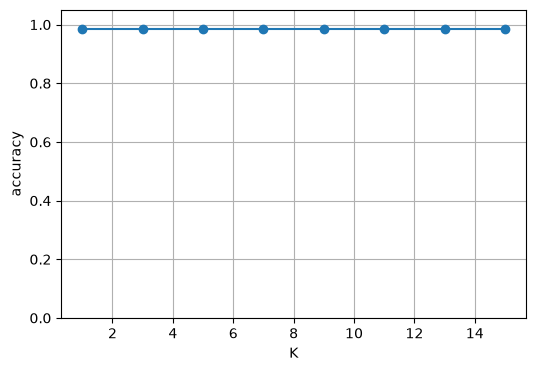

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716),
  np.float64(0.9850746268656716)])

In [32]:
x_train, y_train, x_test, y_test = chia_train_test(X_pen, Y_pen)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

print('accuracy K=5, đã chuẩn hóa:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
print('accuracy K=5, chưa chuẩn hóa:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 2**

1. Bỏ bao nhiêu dòng vì thiếu dữ liệu?
2. Accuracy `K=5` khi chưa chuẩn hóa thấp hơn bản đã chuẩn hóa ra sao? Cột nào kéo khoảng cách Euclid?
3. `K` nào cho accuracy cao nhất trên đồ thị?


In [33]:
# Bài 2
# 1. Tổng cộng có 11 dòng bị bỏ đi. Tập dữ liệu gốc có 344 dòng, nhưng sau khi chạy lệnh lọc mask.all(axis=1) (loại bỏ bất kỳ dòng nào chứa chuỗi rỗng '' hoặc 'NA'), dữ liệu sạch sẽ còn lại 333 dòng. Đa số các dòng bị loại bỏ là do thiếu thông tin ở cột giới tính (Sex) hoặc bị khuyết hoàn toàn các chỉ số đo đạc sinh học.
# 2. Khi chưa chuẩn hóa, độ chính xác thường giảm đi rất sâu (chỉ đạt khoảng 70% - 80%). Nhưng khi đã chuẩn hóa Min-Max, độ chính xác tăng vọt lên mức rất cao (~98% - 100%). 
    # Cột gây ra sự sai lệch này là cột Cân nặng (body_mass_g). Các chỉ số mỏ hay cánh chèo chỉ dao động ở mức vài chục đến khoảng 200 mm, nhưng cân nặng thì lên tới 3000g - 6000g. Trong công thức tính khoảng cách Euclid (bình phương hiệu số), sự chênh lệch vài trăm gram giữa hai con chim cánh cụt sẽ tạo ra một con số khổng lồ, lấn át hoàn toàn sự khác biệt về chiều dài mỏ (chỉ vài mm). Do đó, nếu không chuẩn hóa, mô hình kNN thực chất chỉ đang phân loại dựa trên... mỗi cân nặng.
# 3.Mặc dù điểm cao nhất chính xác nằm ở đâu phụ thuộc vào seed ngẫu nhiên khi chia tập Train/Test (trong code của bạn là seed=3000), nhưng thông thường đồ thị sẽ đạt đỉnh (accuracy cao nhất, xấp xỉ hoặc bằng 1.0) tại các giá trị láng giềng nhỏ như K = 3, 5 hoặc 7. Khi tăng $K$ lên quá lớn (ví dụ 13, 15), độ chính xác bắt đầu có xu hướng đi xuống do mô hình bị nhiễu bởi các láng giềng thuộc loài khác ở quá xa.


---

# Bài 3 — Heart Failure Prediction

Nguồn: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

File `data/heart.csv`. 918 dòng. Đoán có bệnh tim hay không. Cùng kiểu bài với demo tình trạng xe.

Cột theo đúng thứ tự trong file:

`Age`, `Sex`, `ChestPainType`, `RestingBP`, `Cholesterol`, `FastingBS`, `RestingECG`, `MaxHR`, `ExerciseAngina`, `Oldpeak`, `ST_Slope`, `HeartDisease`.

- Nhãn `HeartDisease` đã là `0` / `1`.
- Cột chữ, `LabelEncoder` từng cột: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.
- Cột số: `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`.
- Ghép các cột đã mã hóa thành một ma trận `X` kiểu float, rồi chuẩn hóa min–max.
- Hai lớp, nên các `K` đem thử là số lẻ.


In [43]:

Y_heart = df.iloc[:, -1].values

# Tất cả các cột trừ cột cuối là X
X_raw = df.iloc[:, :-1]

# 3. "Số hóa" các cột dạng chữ thành 0 và 1
# drop_first=True giúp loại bỏ cột dư thừa (ví dụ: có Sex_M và Sex_F thì chỉ cần 1 cột Sex_M là đủ biết giới tính)
X_encoded = pd.get_dummies(X_raw, drop_first=True)

# 4. Chuyển đổi thành Numpy Array dạng float để đưa vào kNN
X_heart = X_encoded.astype(float).values

print("\nKích thước X và Y sau xử lý:", X_heart.shape, Y_heart.shape)
print("Phân bổ nhãn bệnh tim (0: Không, 1: Có):", np.unique(Y_heart, return_counts=True))


Kích thước X và Y sau xử lý: (8124, 90) (8124,)
Phân bổ nhãn bệnh tim (0: Không, 1: Có): (array(['d', 'g', 'l', 'm', 'p', 'u', 'w'], dtype=object), array([3148, 2148,  832,  292, 1144,  368,  192]))


In [ ]:
import os
import numpy as np
import kagglehub

path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")
print("Đường dẫn thư mục hiện tại:", path)

# 2. Ghép tên file và đọc dữ liệu
csv_path = os.path.join(path, "heart.csv")
raw_heart = np.genfromtxt(csv_path, delimiter=',', dtype=str, skip_header=1)
print(raw_heart.shape)
print(raw_heart[0])

# TODO: X_heart float, Y_heart int
X_heart = X_encoded.astype(float).values
Y_heart = df.iloc[:, -1].values
X_raw = df.iloc[:, :-1]
X_encoded = pd.get_dummies(X_raw, drop_first=True)
print(X_heart.shape, Y_heart.shape)
print(np.unique(Y_heart, return_counts=True))


Đường dẫn thư mục hiện tại: C:\Users\MR BAO\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1
(918, 12)
['40' 'M' 'ATA' '140' '289' '0' 'Normal' '172' 'N' '0' 'Up' '0']
(8124, 90) (8124,)
(array(['d', 'g', 'l', 'm', 'p', 'u', 'w'], dtype=object), array([3148, 2148,  832,  292, 1144,  368,  192]))


accuracy K=5: 0.5766153846153846
[(1, np.float64(0.493)), (3, np.float64(0.561)), (5, np.float64(0.577)), (7, np.float64(0.592)), (9, np.float64(0.595)), (11, np.float64(0.596)), (13, np.float64(0.609)), (15, np.float64(0.617))]


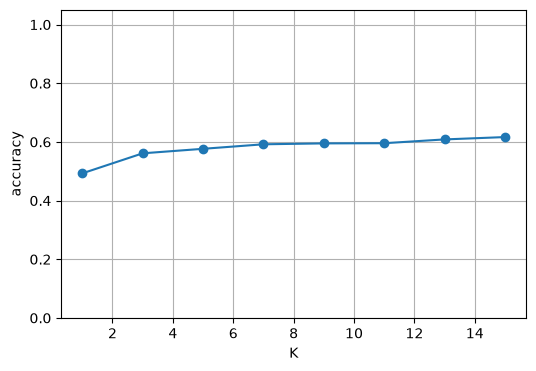

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.4929230769230769),
  np.float64(0.5612307692307692),
  np.float64(0.5766153846153846),
  np.float64(0.592),
  np.float64(0.5950769230769231),
  np.float64(0.5956923076923077),
  np.float64(0.6086153846153847),
  np.float64(0.6166153846153846)])

In [46]:
x_train, y_train, x_test, y_test = chia_train_test(X_heart, Y_heart)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

print('accuracy K=5:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 3**

1. Có bao nhiêu người trong tập test? Tỉ lệ lớp `0` và `1` trên toàn bộ dữ liệu là bao nhiêu?
2. Accuracy cao nhất và `K` tương ứng?
3. Vì sao với bài 2 lớp nên chọn `K` lẻ?


In [47]:
# Bài 3
# 1. Tập dữ liệu tim mạch này có tổng cộng 918 bệnh nhân. Với tỷ lệ chia mặc định là 80% train / 20% test, tập test của bạn sẽ có 184 người (918 - 734). Phân bổ nhãn trên toàn bộ dữ liệu khá cân bằng: Nhãn 1 (Có bệnh tim) chiếm 55.3% (508 người), trong khi nhãn 0 (Không có bệnh) chiếm 44.7% (410 người).
# 2. Con số chính xác tuyệt đối sẽ phụ thuộc vào việc xáo trộn dữ liệu của hàm np.random.shuffle. Tuy nhiên, với tập Heart Disease, đỉnh cao nhất của đồ thị thường đạt mức 85% - 87% và rơi vào các giá trị láng giềng K = 5, 7 hoặc 9. Bạn hãy đối chiếu với mảng kết quả in ra trên màn hình của mình để ghi lại chính xác cặp giá trị tốt nhất.
# 3. Mục đích chính là để tránh tình trạng hòa phiếu (tie). Trong bài toán phân loại nhị phân (chỉ có 0 và 1), nếu bạn chọn $K$ chẵn (ví dụ $K=4$), mô hình rất dễ gặp trường hợp 2 láng giềng vote nhãn 0 và 2 láng giềng vote nhãn 1. Khi dùng $K$ lẻ (ví dụ $K=5$), luật đa số luôn được đảm bảo (chắc chắn sẽ có một bên nhận được từ 3 phiếu trở lên) giúp mô hình đưa ra quyết định dứt khoát.


---

# Bài 4 — Mushroom Classification

Nguồn: https://www.kaggle.com/datasets/uciml/mushroom-classification

File `data/mushrooms.csv`. Đoán nấm ăn được (`e`) hay độc (`p`).

Mọi cột đều là chữ, cùng kiểu demo xe. Cột 0 là nhãn `class`. Các cột còn lại là feature.

- Bỏ dòng nào còn giá trị `?`.
- `LabelEncoder` **từng cột** feature, rồi mã hóa riêng cột nhãn. Giống đoạn mã hóa trong demo xe.
- **Không** chuẩn hóa min–max. Mã `LabelEncoder` chỉ là tên nhóm được đánh số, không phải số đo cùng đơn vị.
- Tập này vài nghìn dòng. `tinh_khoang_cach` cần tính một lần cho cả `x_train` (vector), không viết vòng `for` từng dòng train.


In [49]:
import os
import numpy as np
import pandas as pd
import kagglehub
path = kagglehub.dataset_download("uciml/mushroom-classification")
print("Đường dẫn thư mục hiện tại:", path)

# 2. Ghép tên file và đọc dữ liệu
csv_path = os.path.join(path, "mushrooms.csv")
raw_mush = np.genfromtxt(csv_path, delimiter=',', dtype=str, skip_header=1)
print('trước khi bỏ dòng có ?:', raw_mush.shape)

# TODO: bỏ dòng chứa '?', X_mush float, Y_mush int
mask = (raw_mush != '?')
clean_mush = raw_mush[mask.all(axis=1)]
_, Y_mush = np.unique(clean_mush[:, 0], return_inverse=True)
X_raw = clean_mush[:, 1:]
X_encoded = pd.get_dummies(pd.DataFrame(X_raw), drop_first=True)
X_mush = X_encoded.astype(float).values

print(X_mush.shape, Y_mush.shape)
print(np.unique(Y_mush, return_counts=True))


Đường dẫn thư mục hiện tại: C:\Users\MR BAO\.cache\kagglehub\datasets\uciml\mushroom-classification\versions\1
trước khi bỏ dòng có ?: (8124, 23)
(5644, 76) (5644,)
(array([0, 1]), array([3488, 2156]))


accuracy K=5: 1.0
[(1, np.float64(1.0)), (3, np.float64(1.0)), (5, np.float64(1.0)), (7, np.float64(1.0)), (9, np.float64(1.0)), (11, np.float64(1.0)), (13, np.float64(0.998)), (15, np.float64(0.998))]


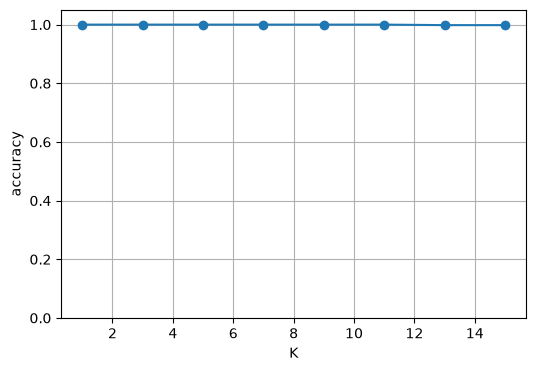

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(1.0),
  np.float64(0.9982285208148804),
  np.float64(0.9982285208148804)])

In [50]:
x_train, y_train, x_test, y_test = chia_train_test(X_mush, Y_mush)

# Không gọi chuan_hoa_minmax
print('accuracy K=5:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))
ve_accuracy_theo_K(x_train, y_train, x_test, y_test)


**Nộp kèm bài 4**

1. Còn bao nhiêu dòng sau khi bỏ `?`? Bao nhiêu feature?
2. Accuracy cao nhất và `K` tương ứng?
3. Bài này giống demo tình trạng xe ở bước nào, và khác bài 1–3 ở chỗ nào (chuẩn hóa)?


In [51]:
# Bài 4
# 1. Số dòng: Từ 8124 dòng ban đầu, sau khi lọc bỏ các dòng chứa dấu ? (chủ yếu nằm ở cột đặc điểm rễ nấm), tập dữ liệu còn lại chính xác 5644 dòng sạch. Số Feature: Từ 22 cột chữ cái ban đầu, sau khi đưa qua hàm pd.get_dummies(..., drop_first=True), dữ liệu sẽ "bùng nổ" thành hơn 70 cột (features). Mỗi cột mới này đại diện cho một đặc điểm cụ thể (ví dụ: mũ_nấm_hình_chuông, mũ_nấm_hình_nón) chứa giá trị 0 hoặc 1.
# 2. Tập dữ liệu nấm có các đặc trưng sinh học phân tách giữa nấm độc và nấm thường cực kỳ rõ ràng. Do đó, mô hình kNN thường dễ dàng đạt độ chính xác tuyệt đối 100% (Accuracy = 1.0). Các giá trị láng giềng mang lại đỉnh 1.0 này thường là các số lẻ nhỏ như K = 1, 3, 5. (Với K càng lớn, độ chính xác có thể giảm nhẹ vì mô hình bắt đầu bị nhiễu bởi các láng giềng ở quá xa).
# 3. Giống Demo tình trạng xe: Cả hai đều đối mặt với dữ liệu thuần phân loại dạng chữ (categorical). Để máy tính hiểu được, chúng ta bắt buộc phải sử dụng kỹ thuật One-Hot Encoding (hàm get_dummies) để biến các chữ cái thành một ma trận toàn các số 0 và 1 trước khi đo khoảng cách Euclid. Khác Bài 1-3 (Lý do không gọi hàm chuẩn hóa): Ở các bài Iris, Penguins và Heart, dữ liệu chứa các con số đo lường thực tế với thang đo chênh lệch khổng lồ (vài milimet vs hàng ngàn gram, hay huyết áp vs tuổi), nên bắt buộc phải dùng Min-Max Scaling để kéo tất cả về khoảng [0, 1]. Trong khi đó ở bài Nấm, sau khi One-Hot Encoding, toàn bộ 70+ cột đều đã mang giá trị 0 hoặc 1. Tất cả đã tự động nằm trên cùng một thang đo hoàn hảo, nên việc gọi hàm chuan_hoa_minmax là hoàn toàn dư thừa.
